In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD CLEANED DATASETS
# ============================================================


customers = pd.read_csv(
    "cleaned_saas_customers.csv"
)

subscriptions = pd.read_csv(
    "cleaned_saas_subscriptions.csv"
)

usage = pd.read_csv(
    "cleaned_saas_usage.csv"
)

tickets = pd.read_csv(
    "cleaned_saas_tickets.csv"
)

print("=" * 70)
print("MODULE 5 — STATISTICS")
print("=" * 70)

print("\nDatasets loaded successfully.")

MODULE 5 — STATISTICS

Datasets loaded successfully.


In [6]:
# ============================================================
# 2. CONVERT DATE COLUMNS
# ============================================================

customers["SignupDate"] = pd.to_datetime(
    customers["SignupDate"],
    errors="coerce"
)

subscriptions["StartDate"] = pd.to_datetime(
    subscriptions["StartDate"],
    errors="coerce"
)

subscriptions["EndDate"] = pd.to_datetime(
    subscriptions["EndDate"],
    errors="coerce"
)

usage["Month"] = pd.to_datetime(
    usage["Month"],
    errors="coerce"
)


# ============================================================
# 3. CREATE SIGNUP COHORT MONTH
# ============================================================

customers["CohortMonth"] = (
    customers["SignupDate"]
    .dt.to_period("M")
)

print("\nSignup cohorts created successfully.")

print(
    customers[
        ["CustomerID", "SignupDate", "CohortMonth"]
    ].head()
)



Signup cohorts created successfully.
  CustomerID SignupDate CohortMonth
0      C1001 2023-07-02     2023-07
1      C1002 2024-02-21     2024-02
2      C1003 2023-09-12     2023-09
3      C1004 2024-03-01     2024-03
4      C1005 2023-12-29     2023-12


In [8]:
# ============================================================
# 4. CREATE CUSTOMER ACTIVITY MONTH
# ============================================================

# Usage activity is used to determine whether a customer
# was active during a particular month.

usage["ActivityMonth"] = (
     usage["Month"]
    .dt.to_period("M")
)

customer_activity = (
    usage[
        ["CustomerID", "ActivityMonth"]
    ]
    .dropna()
    .drop_duplicates()
)

print("\nCustomer activity table created.")
print(customer_activity.head())


Customer activity table created.
  CustomerID ActivityMonth
0      C1001       2023-07
1      C1001       2023-08
2      C1001       2023-09
3      C1001       2023-10
4      C1001       2023-11


In [13]:
# ============================================================
# 5. MERGE COHORT INFORMATION WITH ACTIVITY
# ============================================================

cohort_activity = customer_activity.merge(
    customers[
        ["CustomerID", "CohortMonth"]
    ],
    on="CustomerID",
    how="left"
)

cohort_activity = cohort_activity.dropna(
    subset=["CohortMonth", "ActivityMonth"]
)


# ============================================================
# 6. CALCULATE MONTHS SINCE SIGNUP
# ============================================================

cohort_activity["CohortIndex"] = (
    (
        cohort_activity["ActivityMonth"].dt.year
        - cohort_activity["CohortMonth"].dt.year
    ) * 12
    +
    (
        cohort_activity["ActivityMonth"].dt.month
        - cohort_activity["CohortMonth"].dt.month
    )
)

# Keep only activity occurring from signup month onwards

cohort_activity = cohort_activity[
    cohort_activity["CohortIndex"] >= 0
]

print("\nCohort index calculated successfully.")


# ============================================================
# 7. COUNT CUSTOMERS IN EACH COHORT
# ============================================================

cohort_sizes = (
    customers
    .groupby("CohortMonth")["CustomerID"]
    .nunique()
)

print("\nCohort sizes:")
print(cohort_sizes)


Cohort index calculated successfully.

Cohort sizes:
CohortMonth
2023-01    11
2023-02    16
2023-03    19
2023-04    19
2023-05    25
2023-06    16
2023-07    20
2023-08    16
2023-09    15
2023-10    13
2023-11    15
2023-12    17
2024-01    10
2024-02    16
2024-03    24
2024-04    14
2024-05    14
2024-06    18
2024-07    16
2024-08    26
2024-09    15
2024-10    18
2024-11    19
2024-12    14
2025-01    14
Freq: M, Name: CustomerID, dtype: int64


In [14]:
# ============================================================
# 8. COUNT ACTIVE CUSTOMERS BY COHORT AND MONTH
# ============================================================

active_customers = (
    cohort_activity
    .groupby(
        ["CohortMonth", "CohortIndex"]
    )["CustomerID"]
    .nunique()
)

print("\nActive customers by cohort:")
print(active_customers.head(10))


Active customers by cohort:
CohortMonth  CohortIndex
2023-01      0              11
             1              11
             2              11
             3              11
             4              11
             5              11
             6              11
             7              11
             8              11
             9              11
Name: CustomerID, dtype: int64


In [15]:
# ============================================================
# 9. CREATE RETENTION TABLE
# ============================================================

retention_table = (
    active_customers
    .unstack(fill_value=0)
)

# Divide active customers by original cohort size

retention_rate = retention_table.divide(
    cohort_sizes,
    axis=0
) * 100

retention_rate = retention_rate.round(2)

print("\n" + "=" * 70)
print("COHORT RETENTION TABLE (%)")
print("=" * 70)

print(retention_rate)


COHORT RETENTION TABLE (%)
CohortIndex     0      1       2       3       4       5       6       7   \
CohortMonth                                                                 
2023-01      100.0  100.0  100.00  100.00  100.00  100.00  100.00  100.00   
2023-02      100.0  100.0  100.00  100.00  100.00   93.75   93.75   93.75   
2023-03      100.0  100.0  100.00  100.00   94.74   84.21   84.21   89.47   
2023-04      100.0  100.0   94.74   94.74   94.74   94.74   94.74   94.74   
2023-05      100.0  100.0  100.00  100.00   96.00   96.00   92.00   92.00   
2023-06      100.0  100.0  100.00   93.75   93.75   93.75   93.75   93.75   
2023-07      100.0  100.0  100.00  100.00  100.00  100.00   95.00  100.00   
2023-08      100.0  100.0  100.00  100.00  100.00  100.00   93.75   87.50   
2023-09      100.0  100.0  100.00  100.00  100.00  100.00  100.00  100.00   
2023-10      100.0  100.0  100.00  100.00  100.00  100.00  100.00  100.00   
2023-11      100.0  100.0  100.00  100.00   93.3

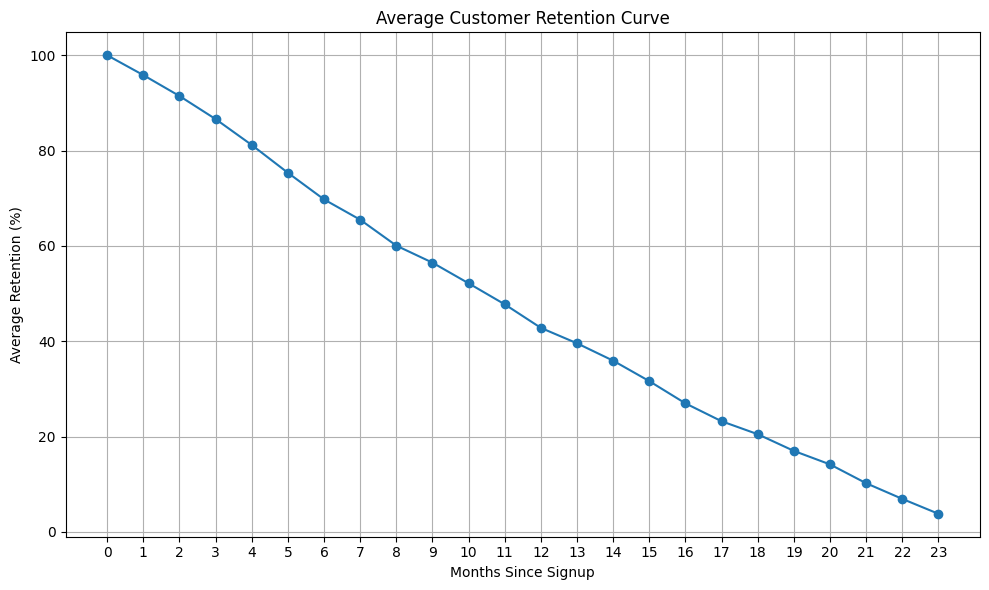

In [16]:
# ============================================================
# 10. CREATE RETENTION CURVE
# ============================================================

average_retention = retention_rate.mean(
    axis=0
)

plt.figure(figsize=(10, 6))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o"
)

plt.title("Average Customer Retention Curve")
plt.xlabel("Months Since Signup")
plt.ylabel("Average Retention (%)")
plt.xticks(average_retention.index)
plt.grid(True)

plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# 11. RETENTION AT SPECIFIC MONTHS
# ============================================================

retention_summary = pd.DataFrame({
    "Month": average_retention.index,
    "Average_Retention_Percentage": average_retention.values
})

print("\n" + "=" * 70)
print("AVERAGE RETENTION CURVE DATA")
print("=" * 70)

print(retention_summary.round(2))


AVERAGE RETENTION CURVE DATA
    Month  Average_Retention_Percentage
0       0                        100.00
1       1                         95.83
2       2                         91.45
3       3                         86.60
4       4                         81.17
5       5                         75.34
6       6                         69.75
7       7                         65.49
8       8                         60.05
9       9                         56.48
10     10                         52.15
11     11                         47.74
12     12                         42.79
13     13                         39.56
14     14                         35.91
15     15                         31.62
16     16                         26.96
17     17                         23.21
18     18                         20.49
19     19                         16.98
20     20                         14.15
21     21                         10.20
22     22                          6.91
23     23 

In [18]:
# ============================================================
# 12. IDENTIFY BEST AND WORST COHORTS
# ============================================================

# Use Month 1 retention when available because older cohorts
# may have more observation time than newer cohorts.

month_1_retention = retention_rate[1].dropna()

if len(month_1_retention) > 0:

    best_cohort = month_1_retention.idxmax()
    worst_cohort = month_1_retention.idxmin()

    best_value = month_1_retention.max()
    worst_value = month_1_retention.min()

    print("\n" + "=" * 70)
    print("BEST AND WORST COHORTS")
    print("=" * 70)

    print(
        "Best cohort based on Month 1 retention:",
        best_cohort
    )

    print(
        "Month 1 retention:",
        round(best_value, 2),
        "%"
    )

    print(
        "\nWorst cohort based on Month 1 retention:",
        worst_cohort
    )

    print(
        "Month 1 retention:",
        round(worst_value, 2),
        "%"
    )

else:

    print(
        "\nMonth 1 retention is not available "
        "for enough cohorts to compare."
    )



BEST AND WORST COHORTS
Best cohort based on Month 1 retention: 2023-01
Month 1 retention: 100.0 %

Worst cohort based on Month 1 retention: 2024-12
Month 1 retention: 0.0 %


In [19]:
# ============================================================
# 13. COMPARE RETENTION CHANGES
# ============================================================

if len(month_1_retention) > 0:

    retention_change = (
        best_value - worst_value
    )

    print(
        "\nRetention difference between best "
        "and worst cohorts:",
        round(retention_change, 2),
        "percentage points"
    )


Retention difference between best and worst cohorts: 100.0 percentage points


In [20]:

# ============================================================
# 14. CREATE COHORT SUMMARY
# ============================================================

cohort_summary = (
    customers
    .groupby("CohortMonth")
    .agg(
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

if 1 in retention_rate.columns:

    cohort_summary = cohort_summary.merge(
        retention_rate[1]
        .rename("Month_1_Retention"),
        left_on="CohortMonth",
        right_index=True,
        how="left"
    )

if 2 in retention_rate.columns:

    cohort_summary = cohort_summary.merge(
        retention_rate[2]
        .rename("Month_2_Retention"),
        left_on="CohortMonth",
        right_index=True,
        how="left"
    )

if 3 in retention_rate.columns:

    cohort_summary = cohort_summary.merge(
        retention_rate[3]
        .rename("Month_3_Retention"),
        left_on="CohortMonth",
        right_index=True,
        how="left"
    )

print("\n" + "=" * 70)
print("COHORT SUMMARY")
print("=" * 70)

print(cohort_summary.round(2))


COHORT SUMMARY
   CohortMonth  Customers  Month_1_Retention  Month_2_Retention  \
0      2023-01         11              100.0             100.00   
1      2023-02         16              100.0             100.00   
2      2023-03         19              100.0             100.00   
3      2023-04         19              100.0              94.74   
4      2023-05         25              100.0             100.00   
5      2023-06         16              100.0             100.00   
6      2023-07         20              100.0             100.00   
7      2023-08         16              100.0             100.00   
8      2023-09         15              100.0             100.00   
9      2023-10         13              100.0             100.00   
10     2023-11         15              100.0             100.00   
11     2023-12         17              100.0             100.00   
12     2024-01         10              100.0             100.00   
13     2024-02         16              100.0  

In [21]:

# ============================================================
# 15. SAVE MODULE 6 OUTPUTS
# ============================================================

retention_rate.to_csv(
    "module6_cohort_retention_table.csv"
)

retention_summary.to_csv(
    "module6_retention_curve.csv",
    index=False
)

cohort_summary.to_csv(
    "module6_cohort_summary.csv",
    index=False
)

cohort_activity.to_csv(
    "module6_customer_cohort_activity.csv",
    index=False
)


print("\n" + "=" * 70)
print("MODULE 6 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nFiles saved:")
print("1. module6_cohort_retention_table.csv")
print("2. module6_retention_curve.csv")
print("3. module6_cohort_summary.csv")
print("4. module6_customer_cohort_activity.csv")


MODULE 6 COMPLETED SUCCESSFULLY

Files saved:
1. module6_cohort_retention_table.csv
2. module6_retention_curve.csv
3. module6_cohort_summary.csv
4. module6_customer_cohort_activity.csv


In [ ]:
How retention is calculated

For each signup cohort:

Retention Rate= Active customers in a month / Customers in the original cohort × 100

For example, if 100 customers signed up in January and 70 of them were active one month later:

Month 1 Retention= 70/100 ×100=70%

Meaning of CohortIndex
Meaning
0 - Signup month
1 - One month after signup
2 - Two months after signup
3 - Three months after signup